# Model Training

Imports

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit, train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import randint

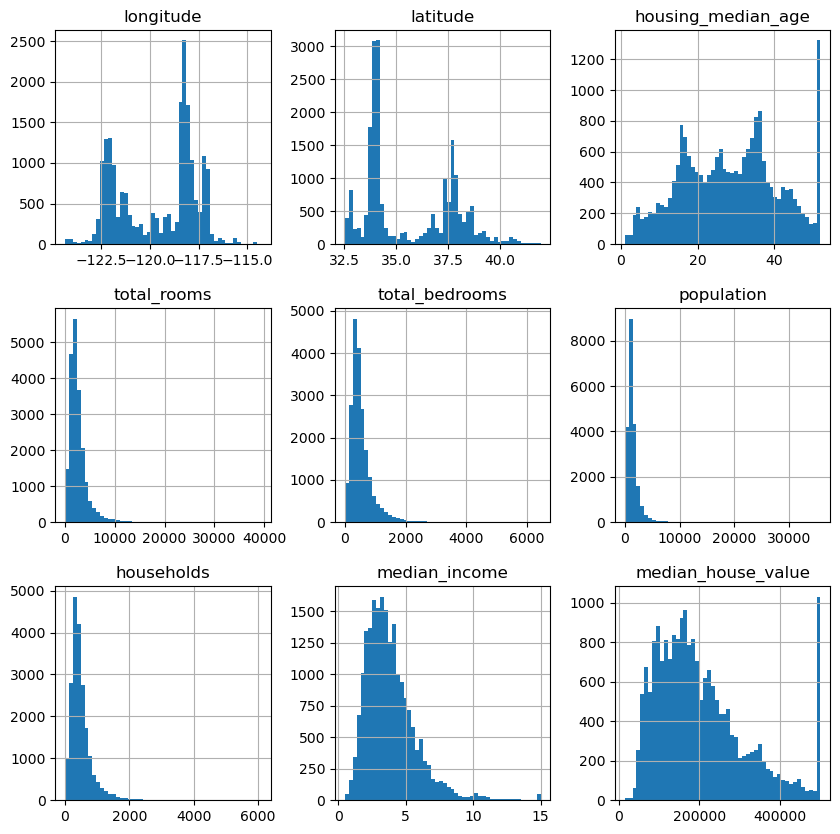

In [92]:
housing_orginal = pd.read_csv("datasets/housing/housing.csv")
housing_orginal.hist(bins=50, figsize=(10, 10))
plt.show()

In [93]:
housing_orginal["income_category"] = pd.cut(housing_orginal["median_income"], bins = (0, 1.5, 3, 4.5, 6, 7.5, np.inf), labels=("mid_low","upper_low","low_mid", "mid", "upper_mid", "rich"))
housing_orginal["income_category"].value_counts()

income_category
low_mid      7236
upper_low    6581
mid          3639
upper_mid    1423
rich          939
mid_low       822
Name: count, dtype: int64

In [94]:
testSetSplitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state = 42)
trainindices, Testindices = next(testSetSplitter.split(housing_orginal, housing_orginal["income_category"]))
trainTestSets = [housing_orginal.iloc[trainindices], housing_orginal.iloc[Testindices]]
housing_orginal.shape, trainTestSets[0].shape, trainTestSets[1].shape

((20640, 11), (16512, 11), (4128, 11))

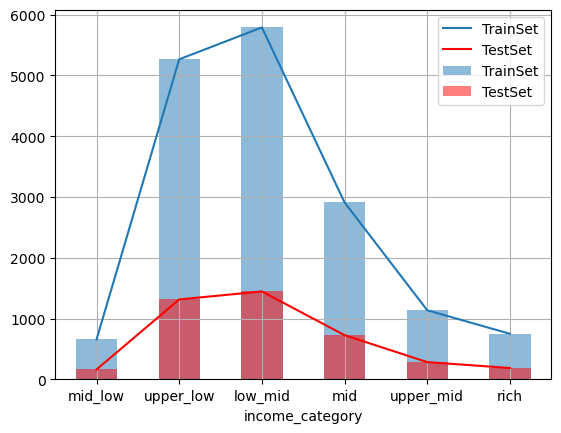

In [95]:
trainTestSets[0]["income_category"].value_counts().sort_index().plot.bar(grid = True, rot = 0, label = "TrainSet", alpha = 0.5)
trainTestSets[0]["income_category"].value_counts().sort_index().plot(grid = True, rot = 0, label = "TrainSet")
trainTestSets[1]["income_category"].value_counts().sort_index().plot.bar(grid = True, color = "red", rot = 0, label = "TestSet", alpha = 0.5)
trainTestSets[1]["income_category"].value_counts().sort_index().plot(grid = True, color = "red", rot = 0, label = "TestSet")
plt.legend(loc="best")

In [96]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_category"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_orginal, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_orginal),
    "Stratified %": income_cat_proportions(trainTestSets[1]),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
mid_low,3.98,3.97,4.24,-0.24,6.45
upper_low,31.88,31.88,30.74,-0.02,-3.59
low_mid,35.06,35.05,34.52,-0.01,-1.53
mid,17.63,17.64,18.41,0.03,4.42
upper_mid,6.89,6.90,7.27,0.14,5.41
rich,4.55,4.55,4.82,0.11,5.96


In [97]:
for df in trainTestSets:
    df.drop("income_category", inplace = True, axis=1)

C:\Users\momin\AppData\Local\Temp\ipykernel_3308\3504330357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("income_category", inplace = True, axis=1)
C:\Users\momin\AppData\Local\Temp\ipykernel_3308\3504330357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("income_category", inplace = True, axis=1)


In [98]:
trainTestSets[0]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1884,-115.53,34.91,12.0,807.0,199.0,246.0,102.0,2.5391,40000.0,INLAND
756,-121.87,37.41,24.0,3308.0,548.0,1891.0,544.0,5.6683,248700.0,<1H OCEAN
11391,-118.37,36.19,10.0,443.0,111.0,48.0,21.0,3.1250,71300.0,INLAND
7866,-117.29,34.06,7.0,1971.0,403.0,1336.0,423.0,4.5066,111500.0,INLAND
14189,-117.37,33.94,20.0,1682.0,296.0,706.0,291.0,4.0966,140100.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
2353,-117.90,34.12,33.0,1555.0,361.0,1571.0,386.0,4.0529,138200.0,<1H OCEAN
13409,-118.04,34.17,52.0,1885.0,401.0,764.0,373.0,4.0385,265700.0,INLAND
7290,-118.46,35.12,16.0,4084.0,812.0,2033.0,668.0,3.2405,85500.0,INLAND
15384,-117.96,34.00,33.0,5462.0,952.0,3527.0,914.0,4.4038,186700.0,<1H OCEAN


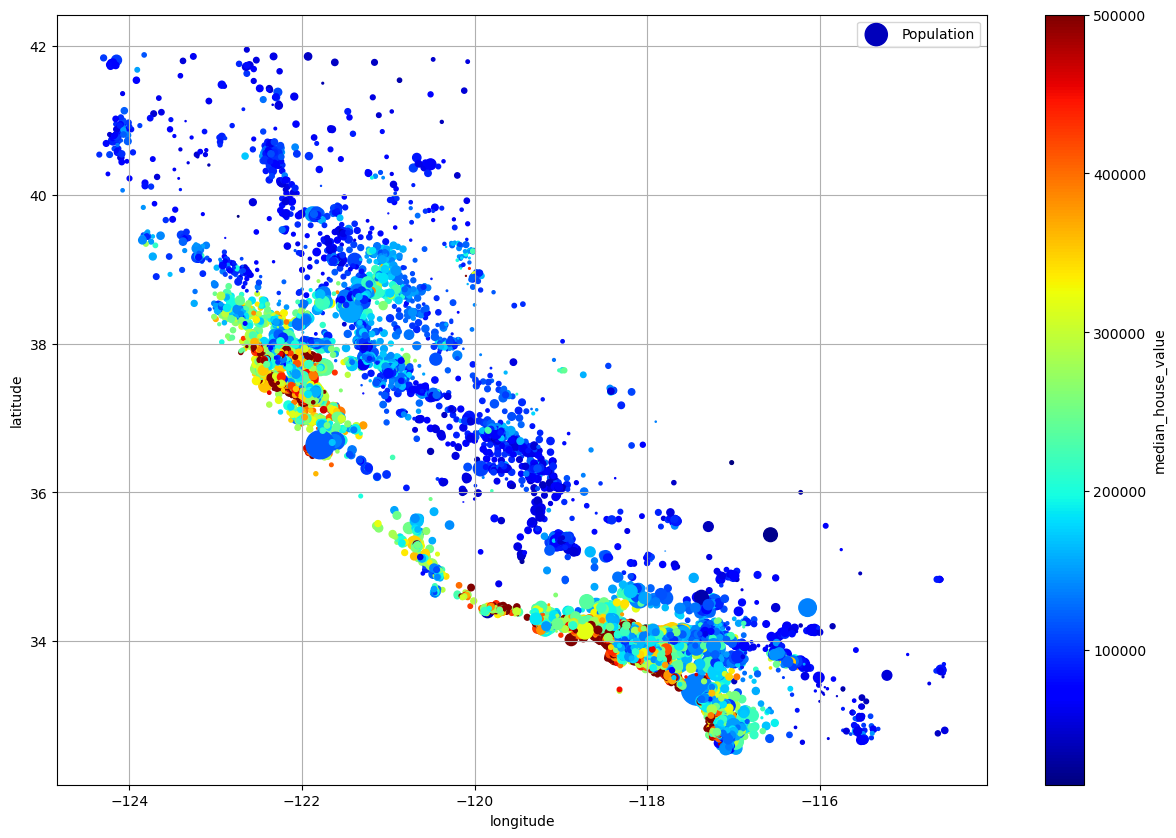

In [99]:
trainTestSets[0].plot.scatter(x="longitude", y = "latitude", c = "median_house_value", cmap = "jet", s =  trainTestSets[0]["population"]/70, figsize = (15, 10), grid = True, label = "Population")
plt.show()

In [100]:
class clusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_cluster = 10, gamma = 1.0, random_state = None):
        self.n_cluster= n_cluster
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, Y=None, sample_weight = None):
        self.kMeans = KMeans(n_clusters=self.n_cluster, random_state=self.random_state, n_init=10)
        self.kMeans.fit(X, sample_weight=sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kMeans.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names = None):
        return [f"Cluster {i}" for i in range(self.n_cluster)]


In [101]:
cm = clusterSimilarity(10, 1.0)
similarities = cm.fit_transform(trainTestSets[0][["latitude", "longitude"]]).round(2)
similarities

array([[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.61, 0.  , 0.  , ..., 0.97, 0.  , 0.  ],
       [0.  , 0.  , 0.19, ..., 0.  , 0.01, 0.03],
       ...,
       [0.  , 0.12, 0.03, ..., 0.  , 0.31, 0.21],
       [0.  , 0.91, 0.  , ..., 0.  , 0.89, 0.02],
       [0.  , 0.51, 0.  , ..., 0.  , 0.96, 0.12]], shape=(16512, 10))

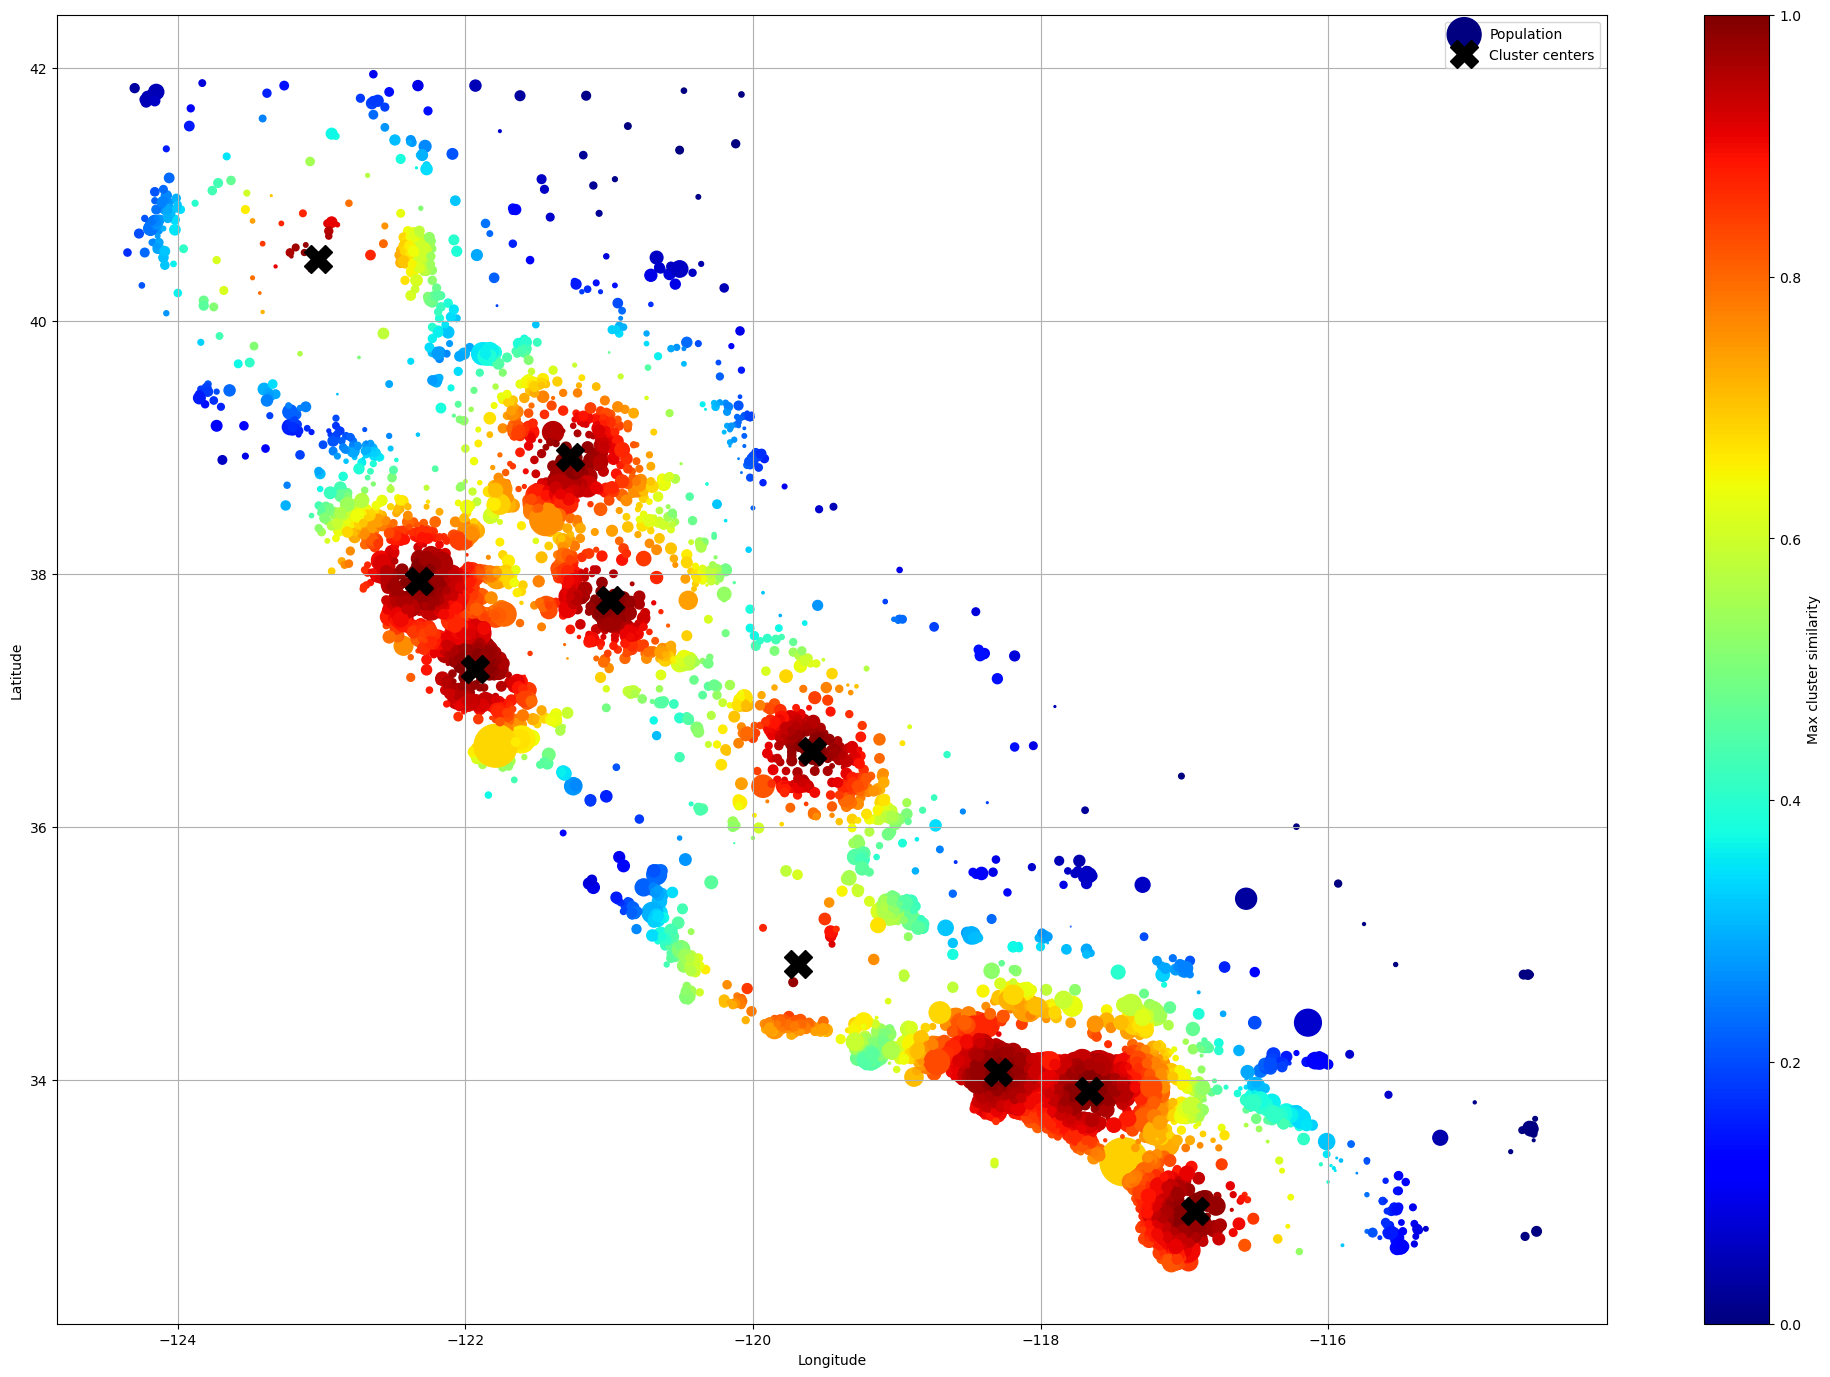

In [102]:
# extra code – this cell generates Figure 2–19

housing_renamed = trainTestSets[0].rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 30, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(25, 17))
plt.plot(cm.kMeans.cluster_centers_[:, 1],
         cm.kMeans.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
plt.savefig("district_cluster.png")
plt.show()